## Import Library

In [42]:

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("TensorFlow version:", tf.__version__)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH      = "dataset/sayur_buah_cleaned_result.csv"
MODEL_PATH     = "model.keras"
METADATA_PATH  = "model_metadata.json"
print("Setup selesai.")


TensorFlow version: 2.16.1
Setup selesai.


## Load & Eksplorasi Data

In [43]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")
print()
print(df.head())
print()
print("Statistik dasar:")
print(df.describe())
print()
print("Distribusi sisa_hari per label:")
print(df.groupby("label")["sisa_hari"].agg(["mean","min","max","count"]))
print()
print("Distribusi sisa_hari per lokasi:")
print(df.groupby("lokasi_penyimpanan")["sisa_hari"].agg(["mean","min","max"]))


Shape: (3723, 6)
Kolom: ['nama_item', 'jenis_item', 'lokasi_penyimpanan', 'hari_sejak_pembelian', 'sisa_hari', 'label']

  nama_item jenis_item lokasi_penyimpanan  hari_sejak_pembelian  sisa_hari  \
0    Mangga       Buah            Pembeku                     0       33.7   
1     Timun      Sayur         Suhu Ruang                     2        1.3   
2     Tomat      Sayur          Pendingin                     0        2.5   
3      Apel       Buah         Suhu Ruang                     4       16.2   
4     Tomat      Sayur         Suhu Ruang                     1        0.1   

    label  
0  Matang  
1   Busuk  
2   Busuk  
3  Mentah  
4   Busuk  

Statistik dasar:
       hari_sejak_pembelian    sisa_hari
count           3723.000000  3723.000000
mean               1.995165    11.486248
std                1.785811    10.714683
min                0.000000     0.000000
25%                1.000000     2.600000
50%                2.000000     8.200000
75%                3.000000    17

## Analisis Noise Floor & Upper-Bound Lookup Table

In [44]:
# Noise floor = std deviasi di dalam grup yang sama (item, lokasi, label identik)
within_std = df.groupby(["nama_item","lokasi_penyimpanan","label"])["sisa_hari"].std().dropna()
print(f"Within-group std (mean)  : {within_std.mean():.4f} hari")
print(f"Within-group std (median): {within_std.median():.4f} hari")
print()
print("Artinya: noise inherent dalam data sekitar 2.5 hari.")
print("MAE teoritis minimum mendekati ~2.0 hari (noise floor dataset).")
print()

# Upper-bound lookup: digunakan untuk mencegah overprediction berbahaya
upper_bound_lookup = (
    df.groupby(["nama_item", "lokasi_penyimpanan"])["sisa_hari"]
    .max()
    .to_dict()
)
print("Upper-bound lookup (item + lokasi -> max sisa_hari aktual):")
for k, v in upper_bound_lookup.items():
    print(f"  {k[0]:10s} + {k[1]:12s} -> {v:.1f} hari")


Within-group std (mean)  : 2.4875 hari
Within-group std (median): 1.9170 hari

Artinya: noise inherent dalam data sekitar 2.5 hari.
MAE teoritis minimum mendekati ~2.0 hari (noise floor dataset).

Upper-bound lookup (item + lokasi -> max sisa_hari aktual):
  Anggur     + Pembeku      -> 41.5 hari
  Anggur     + Pendingin    -> 27.8 hari
  Anggur     + Suhu Ruang   -> 13.4 hari
  Apel       + Pembeku      -> 42.0 hari
  Apel       + Pendingin    -> 32.4 hari
  Apel       + Suhu Ruang   -> 16.6 hari
  Cabe       + Pembeku      -> 41.2 hari
  Cabe       + Pendingin    -> 29.9 hari
  Cabe       + Suhu Ruang   -> 14.8 hari
  Jeruk      + Pembeku      -> 41.9 hari
  Jeruk      + Pendingin    -> 35.7 hari
  Jeruk      + Suhu Ruang   -> 17.9 hari
  Kentang    + Pembeku      -> 39.6 hari
  Kentang    + Pendingin    -> 41.4 hari
  Kentang    + Suhu Ruang   -> 20.8 hari
  Mangga     + Pembeku      -> 41.4 hari
  Mangga     + Pendingin    -> 24.5 hari
  Mangga     + Suhu Ruang   -> 12.4 hari
  Pis

## Feature Engineering & Augmentasi Data

In [45]:
# Mapping ordinal kondisi item (semakin besar = semakin segar/lama)
LABEL_ORDER = {"Busuk": 0, "Terlalu Matang": 1, "Matang": 2, "Segar": 3, "Mentah": 4}

# Bobot lokasi penyimpanan (pengaruh terhadap ketahanan)
LOKASI_MULT = {"Suhu Ruang": 1.0, "Pendingin": 1.8, "Pembeku": 3.5}

def engineer_features(dataframe):
    df_eng = dataframe.copy()
    df_eng["label_score"]    = df_eng["label"].map(LABEL_ORDER)
    df_eng["lokasi_mult"]    = df_eng["lokasi_penyimpanan"].map(LOKASI_MULT)
    df_eng["label_x_lokasi"] = df_eng["label_score"] * df_eng["lokasi_mult"]
    df_eng["hari_x_lokasi"]  = df_eng["hari_sejak_pembelian"] * df_eng["lokasi_mult"]
    return df_eng

df_feat = engineer_features(df)

# Augmentasi data: tambah variasi kecil untuk memperkaya distribusi training
np.random.seed(SEED)
aug_rows = []
for _, row in df.iterrows():
    for _ in range(2):
        new_row = row.copy()
        new_row["sisa_hari"] = max(0.0, row["sisa_hari"] + np.random.normal(0, 0.4))
        aug_rows.append(new_row)

df_aug = pd.concat([df, pd.DataFrame(aug_rows)], ignore_index=True)
df_aug = engineer_features(df_aug)

print(f"Dataset asli     : {len(df)} baris")
print(f"Dataset augmented: {len(df_aug)} baris (3x lipat)")

FEATURE_COLS = [
    "nama_item", "jenis_item", "lokasi_penyimpanan", "label",
    "hari_sejak_pembelian", "label_score", "lokasi_mult",
    "label_x_lokasi", "hari_x_lokasi"
]
CATEGORICAL_COLS = ["nama_item", "jenis_item", "lokasi_penyimpanan", "label"]
NUMERICAL_COLS   = ["hari_sejak_pembelian", "label_score", "lokasi_mult",
                    "label_x_lokasi", "hari_x_lokasi"]
print(f"Total fitur: {len(FEATURE_COLS)}")


Dataset asli     : 3723 baris
Dataset augmented: 11169 baris (3x lipat)
Total fitur: 9


## Encoder & Scaling

In [46]:
# Fit encoder pada data asli agar kelas konsisten saat inference
encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    le.fit(df[col])
    encoders[col] = le

def encode_df(dataframe, encoders):
    df_enc = dataframe.copy()
    for col, le in encoders.items():
        df_enc[col] = le.transform(df_enc[col])
    return df_enc

df_aug_enc  = encode_df(df_aug, encoders)
df_orig_enc = encode_df(engineer_features(df), encoders)

# Data augmented -> untuk training
X_all = df_aug_enc[FEATURE_COLS].values.astype(np.float32)
y_all = df_aug_enc["sisa_hari"].values.astype(np.float32)

# Data original -> untuk evaluasi test
X_orig = df_orig_enc[FEATURE_COLS].values.astype(np.float32)
y_orig = df_orig_enc["sisa_hari"].values.astype(np.float32)

# RobustScaler: tahan terhadap outlier
scaler = RobustScaler()
X_all_scaled  = scaler.fit_transform(X_all)
X_orig_scaled = scaler.transform(X_orig)



## Split Data

In [47]:
# Train-test split dari data asli
# Simpan indices agar Cell 8 bisa lookup nama_item & lokasi yang benar
from sklearn.model_selection import train_test_split as tts
idx_all = np.arange(len(df))
idx_train, idx_test = tts(idx_all, test_size=0.2, random_state=SEED)

X_train = X_orig_scaled[idx_train]
X_test  = X_orig_scaled[idx_test]
y_train = y_orig[idx_train]
y_test  = y_orig[idx_test]

# Simpan df_test_ref dengan index yang benar untuk lookup safe predict
df_test_ref = df.iloc[idx_test].reset_index(drop=True)

print(f"Training (augmented): {X_all_scaled.shape}")
print(f"X_train (asli)      : {X_train.shape}")
print(f"X_test  (asli)      : {X_test.shape}")
print(f"df_test_ref shape   : {df_test_ref.shape}  <- aligned dengan X_test")

ENCODER_CLASSES = {col: le.classes_.tolist() for col, le in encoders.items()}

Training (augmented): (11169, 9)
X_train (asli)      : (2978, 9)
X_test  (asli)      : (745, 9)
df_test_ref shape   : (745, 6)  <- aligned dengan X_test


## Build Model

In [48]:
def build_model(input_dim, dropout_rate=0.25):
    """
    Deep learning model dengan arsitektur feedforward berlapis.
    Menggunakan:
      - BatchNormalization untuk stabilisasi training
      - Dropout untuk mencegah overfitting
      - L2 regularisasi untuk generalisasi lebih baik
      - Huber loss agar robust terhadap outlier
    """
    inputs = keras.Input(shape=(input_dim,), name="input_features")

    x = layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(128, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(64, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Dense(32, activation="relu")(x)

    outputs = layers.Dense(1, name="sisa_hari_pred")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="FreshPredictor")
    return model

model = build_model(input_dim=X_all_scaled.shape[1])
model.summary()


Model: "FreshPredictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sisa_hari_pred (Dense)          │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,617 (186.00 KB)

 Trainable params: 46,721 (182.50 KB)

 Non-trainable params: 896 (3.50 KB)

## Callbacks & Training

In [49]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="huber",     # Lebih robust terhadap outlier dibanding MSE
    metrics=["mae"]
)

callback_list = [
    # 1) Early Stopping: hentikan training jika val_mae tidak membaik
    callbacks.EarlyStopping(
        monitor="val_mae",
        patience=30,
        restore_best_weights=True,
        verbose=1
    ),
    # 2) ReduceLROnPlateau: turunkan LR saat training stagnan
    callbacks.ReduceLROnPlateau(
        monitor="val_mae",
        factor=0.5,
        patience=12,
        min_lr=1e-6,
        verbose=1
    ),
    # 3) ModelCheckpoint: simpan bobot terbaik secara otomatis
    callbacks.ModelCheckpoint(
        filepath="best_weights.keras",
        monitor="val_mae",
        save_best_only=True,
        verbose=0
    ),
]

history = model.fit(
    X_all_scaled, y_all,
    epochs=400,
    batch_size=64,
    validation_split=0.1,
    callbacks=callback_list,
    verbose=1
)

print("Training selesai.")
print(f"Best val_mae: {min(history.history['val_mae']):.4f} hari")


Epoch 1/400
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 4.6598 - mae: 5.0831 - val_loss: 3.8768 - val_mae: 4.2980 - learning_rate: 0.0010
Epoch 2/400
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.6122 - mae: 3.0241 - val_loss: 2.7378 - val_mae: 3.1564 - learning_rate: 0.0010
Epoch 3/400
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.5523 - mae: 2.9661 - val_loss: 2.5565 - val_mae: 2.9791 - learning_rate: 0.0010
Epoch 4/400
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.4954 - mae: 2.9051 - val_loss: 2.5065 - val_mae: 2.9279 - learning_rate: 0.0010
Epoch 5/400
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.4469 - mae: 2.8562 - val_loss: 2.5267 - val_mae: 2.9504 - learning_rate: 0.0010
Epoch 6/400
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.3973 - mae: 2.8057 - val_loss: 2.4738 - val_mae: 2.8961 - learning_rate: 0.0010
Epoch 7/400
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.3691 - mae: 2.7777 - val_loss: 2.4548 - val_mae: 2.8789 - learning_rate: 0.0010

## Plot Training

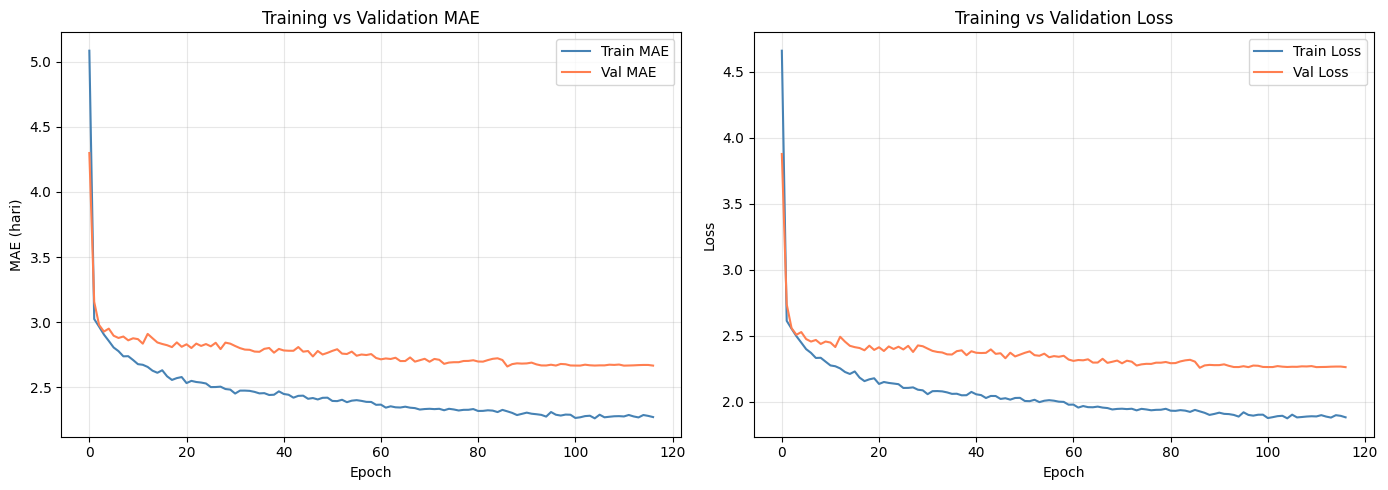

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['mae'],     label='Train MAE', color='steelblue')
axes[0].plot(history.history['val_mae'], label='Val MAE',   color='coral')
axes[0].set_title('Training vs Validation MAE')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MAE (hari)')
axes[0].legend(); axes[0].grid(alpha=0.3)
 
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='coral')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.show()


## Evaluasi & Safe Prediction

In [51]:
y_pred_raw = model.predict(X_test, verbose=0).flatten()

def safe_predict_batch(model, X_scaled, nama_items, lokasi_list,
                       upper_bound_lookup, safety_ratio=0.92):
    """
    Prediksi dengan safety clipping untuk mencegah overprediction berbahaya.

    Logika:
      1. Clip ke 0 (tidak ada prediksi negatif).
      2. Clip ke upper bound historis per kombinasi item+lokasi.
      3. Buffer keamanan 8%: cap di 92% upper bound sebagai margin.
      4. Kembalikan sebagai integer (sisa hari tidak mungkin float).

    Catatan: fungsi ini memakai nama_items & lokasi_list yang HARUS
    sejajar (aligned) dengan baris X_scaled — pastikan urutan sama.
    """
    preds_raw  = model.predict(X_scaled, verbose=0).flatten()
    preds_safe = []
    for pred, item, lokasi in zip(preds_raw, nama_items, lokasi_list):
        ub         = upper_bound_lookup.get((item, lokasi), 42.0)
        safety_cap = ub * safety_ratio
        pred_safe  = int(round(float(np.clip(pred, 0, safety_cap))))
        preds_safe.append(pred_safe)
    return np.array(preds_safe)

# df_test_ref sudah aligned dengan X_test (dibuat di Cell 5)
y_pred_safe = safe_predict_batch(
    model, X_test,
    df_test_ref["nama_item"].tolist(),
    df_test_ref["lokasi_penyimpanan"].tolist(),
    upper_bound_lookup
)

# Raw pred juga dibulatkan ke int untuk konsistensi
y_pred_raw_int = np.array([int(round(float(p))) for p in y_pred_raw])

mae_raw  = mean_absolute_error(y_test, y_pred_raw_int)
mae_safe = mean_absolute_error(y_test, y_pred_safe)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred_raw_int))

print("=" * 50)
print(f"MAE  (raw, int)    : {mae_raw:.4f} hari")
print(f"MAE  (safe, int)   : {mae_safe:.4f} hari")
print(f"RMSE (raw, int)    : {rmse:.4f} hari")
print("=" * 50)

print()
print(f"{'Aktual':>10} | {'Raw (int)':>10} | {'Safe (int)':>10}")
print("-" * 38)
for i in range(min(20, len(y_test))):
    print(f"{y_test[i]:10.1f} | {y_pred_raw_int[i]:10d} | {y_pred_safe[i]:10d}")


MAE  (raw, int)    : 2.3356 hari
MAE  (safe, int)   : 2.3356 hari
RMSE (raw, int)    : 3.4166 hari

    Aktual |  Raw (int) | Safe (int)
--------------------------------------
      21.6 |         16 |         16
       0.7 |          1 |          1
      12.1 |         11 |         11
       8.4 |          6 |          6
      41.3 |         36 |         36
       0.6 |          1 |          1
       8.1 |          8 |          8
      37.5 |         31 |         31
      28.8 |         21 |         21
       3.8 |          3 |          3
      12.4 |         16 |         16
       5.6 |          5 |          5
      30.1 |         26 |         26
       2.6 |          2 |          2
       0.8 |          1 |          1
      29.7 |         32 |         32
      34.8 |         34 |         34
       0.1 |          1 |          1
      24.2 |         26 |         26
       0.3 |          2 |          2


## Save Model

In [52]:
model.save(MODEL_PATH)
print(f"Model disimpan ke: {MODEL_PATH}")

metadata = {
    "model_path"        : MODEL_PATH,
    "input_features"    : FEATURE_COLS,
    "categorical_cols"  : CATEGORICAL_COLS,
    "numerical_cols"    : NUMERICAL_COLS,
    "n_features"        : len(FEATURE_COLS),
    "encoder_classes"   : ENCODER_CLASSES,
    "label_order_mapping": LABEL_ORDER,
    "lokasi_multiplier" : LOKASI_MULT,
    "scaler_params"     : {
        "center_": scaler.center_.tolist(),
        "scale_" : scaler.scale_.tolist()
    },
    "upper_bound_lookup": {
        f"{k[0]}|{k[1]}": float(v)
        for k, v in upper_bound_lookup.items()
    },
    "safety_cap_ratio"  : 0.92,
    "training_info"     : {
        "n_samples_original" : len(df),
        "n_samples_augmented": len(df_aug),
        "test_mae_raw_int"   : float(round(mae_raw, 4)),
        "test_mae_safe_int"  : float(round(mae_safe, 4)),
        "best_val_mae"       : float(round(min(history.history["val_mae"]), 4)),
        "noise_floor_est"    : float(round(within_std.mean(), 4))
    }
}

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata disimpan ke: {METADATA_PATH}")
for k, v in metadata.items():
    if k not in ["encoder_classes", "scaler_params", "upper_bound_lookup"]:
        print(f"  {k}: {v}")


Model disimpan ke: model.keras
Metadata disimpan ke: model_metadata.json
  model_path: model.keras
  input_features: ['nama_item', 'jenis_item', 'lokasi_penyimpanan', 'label', 'hari_sejak_pembelian', 'label_score', 'lokasi_mult', 'label_x_lokasi', 'hari_x_lokasi']
  categorical_cols: ['nama_item', 'jenis_item', 'lokasi_penyimpanan', 'label']
  numerical_cols: ['hari_sejak_pembelian', 'label_score', 'lokasi_mult', 'label_x_lokasi', 'hari_x_lokasi']
  n_features: 9
  label_order_mapping: {'Busuk': 0, 'Terlalu Matang': 1, 'Matang': 2, 'Segar': 3, 'Mentah': 4}
  lokasi_multiplier: {'Suhu Ruang': 1.0, 'Pendingin': 1.8, 'Pembeku': 3.5}
  safety_cap_ratio: 0.92
  training_info: {'n_samples_original': 3723, 'n_samples_augmented': 11169, 'test_mae_raw_int': 2.3356, 'test_mae_safe_int': 2.3356, 'best_val_mae': 2.6599, 'noise_floor_est': 2.4875}


## Inference

In [53]:
with open(METADATA_PATH) as f:
    _meta = json.load(f)
_inference_model = keras.models.load_model(MODEL_PATH, compile=False)

# Pre-extract semua params yang dibutuhkan
_center   = np.array(_meta["scaler_params"]["center_"])
_scale    = np.array(_meta["scaler_params"]["scale_"])
_enc_cls  = _meta["encoder_classes"]
_label_ord = _meta["label_order_mapping"]
_lokasi_m  = _meta["lokasi_multiplier"]
_ub_lookup = _meta["upper_bound_lookup"]
_safety_r  = _meta["safety_cap_ratio"]


def predict_from_api(item, jenis, lokasi, label, hari):
    """
    Fungsi inference end-to-end dengan safe prediction.
    Model & metadata di-load sekali saat notebook dijalankan,
    bukan setiap kali fungsi ini dipanggil.
    """
    def enc(val, classes):
        return classes.index(val) if val in classes else 0

    ls = _label_ord.get(label, 2)
    lm = _lokasi_m.get(lokasi, 1.0)

    X = np.array([[
        enc(item,   _enc_cls["nama_item"]),
        enc(jenis,  _enc_cls["jenis_item"]),
        enc(lokasi, _enc_cls["lokasi_penyimpanan"]),
        enc(label,  _enc_cls["label"]),
        hari, ls, lm, ls * lm, hari * lm
    ]], dtype=np.float32)

    X_scaled = (X - _center) / _scale

    pred_raw = float(_inference_model.predict(X_scaled, verbose=0).flatten()[0])

    ub_key = f"{item}|{lokasi}"
    ub     = _ub_lookup.get(ub_key, 42.0)
    cap    = ub * _safety_r
    pred_safe = int(round(float(np.clip(pred_raw, 0, cap))))

    return {
        "prediksi_sisa_hari": pred_safe,
        "prediksi_raw"      : round(pred_raw, 1),
        "upper_bound"       : ub,
        "safety_cap"        : round(cap, 1),
        "was_clipped"       : pred_raw > cap
    }


# Contoh test inference
test_cases = [
    ("Tomat",  "Sayur", "Suhu Ruang", "Segar",  0),
    ("Apel",   "Buah",  "Pendingin",  "Mentah", 1),
    ("Pisang", "Buah",  "Suhu Ruang", "Matang", 2),
    ("Wortel", "Sayur", "Pembeku",    "Segar",  0),
    ("Mangga", "Buah",  "Pendingin",  "Busuk",  3),
]
print(f"{'Item':10} | {'Lokasi':12} | {'Label':15} | {'Hari':4} | {'Raw':6} | {'Safe':6} | {'Clipped':7}")
print("-" * 75)
for item, jenis, lokasi, label, hari in test_cases:
    r = predict_from_api(item, jenis, lokasi, label, hari)
    print(f"{item:10} | {lokasi:12} | {label:15} | {hari:4} | "
          f"{r['prediksi_raw']:6.1f} | {r['prediksi_sisa_hari']:6d} | {str(r['was_clipped']):7}")


Item       | Lokasi       | Label           | Hari | Raw    | Safe   | Clipped
---------------------------------------------------------------------------
Tomat      | Suhu Ruang   | Segar           |    0 |    9.6 |     10 | False  
Apel       | Pendingin    | Mentah          |    1 |   20.3 |     20 | False  
Pisang     | Suhu Ruang   | Matang          |    2 |    5.9 |      6 | False  
Wortel     | Pembeku      | Segar           |    0 |   31.4 |     31 | False  
Mangga     | Pendingin    | Busuk           |    3 |    0.6 |      1 | False  
